# Offline climatology of poleward heat transport, in $\sigma$

We want to produce this offline climatology for the decomposition of Eddy vs mean CSHT


this code is ran separately for each panan resolution, and we change the code to properly run the model in each resolution

Notice that we only have the proper outputs for sigma climatology calculation in 3 years of run (1999 to 2001), and therefore, this migh not be an optimal solution. I calculated it nevertheless for comparisson


In [1]:
import cosima_cookbook as cc
from cosima_cookbook import distributed as ccd
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import xarray as xr
import glob,os
import cmocean.cm as cmocean

import logging
logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)

from dask.distributed import Client

In [2]:
client = Client(n_workers=28)

In [3]:
	#session = cc.database.create_session('/home/156/wf4500/databases/access/panan005_rerun.db') #panan005
	session = cc.database.create_session('/home/156/wf4500/databases/access/panan01_paralelrun_HT.db') #rerun of panan01
	
	start_time='1999-01-01'     
	end_time='2001-12-31'
	#Start_time0 and end_time0 are for importing the daily transport, and it ahsthe number of days in the month    
	start_time0='1999-01-01'     
	end_time0='2001-12-31'
	print(start_time0) 
	print(end_time0) 
	#exp = 'panant-005-zstar-ACCESSyr2'
	exp = 'panan01_yr2000_HTsigma'
	
	print("Start date =" + start_time) 
	year2=str(int(start_time[0:4])+1)
	month2=str(int(start_time[5:7])+1)
	month2=str(int(month2))
	month2 = month2.zfill(2)    
	print("month2 is =" + month2) 
	print("year2 is =" + str(year2))     
	
	print("End date =" + end_time) 
	
	
	time_period = str(int(start_time[:4]))+'-'+str(int(end_time[:4]))
	
	# reference density value:
	rho_0 = 1035.0
	# specific heat capacity of sea water:
	cp = 3992.1
	lat_range = slice(-90,-59)
	
	isobath_depth = 1000
	
	# pick a freezing point temp:
	temp_freezing = -1.8
	
	

1999-01-01
2001-12-31
Start date =1999-01-01
month2 is =02
year2 is =2000
End date =2001-12-31


Notice that this notebook uses the online transport values instead of the velocities. So the calculation of the heat transport is a little different. The transport is in kg/s, which means we just need to divide it byt the density to get the values in m3/s

In [4]:
	rho_ref=1035 # [kg/m3] reference density value from MOM6 boussinesq approximation
	#Importing tracers and velocities, and calcilating the 10-year climatology
	vhrho_nt = cc.querying.getvar(exp,'vmo',session,frequency='1 monthly',ncfile='%month_rho2%',start_time=start_time,end_time=end_time).sel(time=slice(start_time,end_time))
	vhrho_nt = vhrho_nt/rho_ref
	uhrho_et = cc.querying.getvar(exp,'umo',session,frequency='1 monthly',ncfile='%month_rho2%',start_time=start_time,end_time=end_time).sel(time=slice(start_time,end_time))
	uhrho_et = uhrho_et/rho_ref
	temp = cc.querying.getvar(exp,'thetao',session,frequency='1 monthly',ncfile='%month_rho2%',start_time=start_time,end_time=end_time).sel(time=slice(start_time,end_time))
	
	vhrho_nt = vhrho_nt.sel(yq=lat_range).groupby('time.month').mean('time')
	uhrho_et = uhrho_et.sel(yh=lat_range).groupby('time.month').mean('time')
	temp = temp.sel(yh=lat_range).groupby('time.month').mean('time')

/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3

In [9]:
	#importing volcello and calculating climatology
	volcello = cc.querying.getvar(exp,'volcello',session,frequency='1 monthly',ncfile='%.ocean_month_rho2.nc',start_time=start_time,end_time=end_time).sel(time=slice(start_time,end_time)).sel(yh=lat_range).groupby('time.month').mean('time')


/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/xarray/core/dataset.py:274: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3

In [10]:
	vhrho_nt_xhlim=np.size(vhrho_nt.xh)
	vhrho_nt_yqlim=np.size(vhrho_nt.yq)
	uhrho_et_xqlim=np.size(uhrho_et.xq)
	uhrho_et_yhlim=np.size(uhrho_et.yh)
	uhrho_et_yhlim

510

In [11]:
	xval=int(360/0.1)
xval

3600

In [12]:
	# save a long term average of vhrho_nt and uhrho_et:
	# check if already exists:
	dxCv = cc.querying.getvar(exp,'dxCv',session,n=1).isel(xh=slice(0,xval),yq=slice(1,vhrho_nt_yqlim))
	dxCu = cc.querying.getvar(exp,'dxCu',session,n=1).isel(xq=slice(1,xval+1),yh=slice(0,uhrho_et_yhlim-1))
	dyCu = cc.querying.getvar(exp,'dyCu',session,n=1).isel(xq=slice(1,xval+1),yh=slice(0,uhrho_et_yhlim-1))
	dyCv = cc.querying.getvar(exp,'dyCv',session,n=1).isel(xh=slice(0,xval),yq=slice(1,vhrho_nt_yqlim))

In [13]:
	volcello_v=volcello.rename({'yh':'yq'}); 
	volcello_v['yq']=np.array(dxCv.yq)
	dzt_v=(volcello_v/(dxCv*dyCv))# In the case here dzt is achually the thickness of the who layer
	
	volcello_u=volcello.rename({'xh':'xq'}); 
	volcello_u['xq']=np.array(dxCu.xq)
	dzt_u=(volcello_u/(dxCu*dyCu))

In [14]:
	# this hasnt been loaded yett, so not 100% they have any error in dimentions
	vhrho_nt2 = vhrho_nt
	uhrho_et2 = uhrho_et

In [15]:
	ds = xr.Dataset({'vhrho_nt': vhrho_nt2,'uhrho_et':uhrho_et2})

Continue from here

In [16]:
	
	import os
	#outpath = '/g/data/x77/wf4500/ASC_project/model_data/access-om2/'+exp+'/Antarctic_cross_slope/Daily/uhrho_vhrho_'+start_time+'.nc'
	#ds = xr.open_dataset(outpath)
	vhrho_nt = ds['vhrho_nt']
	uhrho_et = ds['uhrho_et']
	
	# subtract freezing point heat transport:
	yh = cc.querying.getvar(exp,'yh',session,n=1)
	dxu = cc.querying.getvar(exp,'dxCv',session,n=1) #on OM2 is dxu
	dyt = cc.querying.getvar(exp,'dyCu',session,n=1)# on OM2 is dyu
	
	## give dxu and dyt correct coordinates:
	## dxu.coords['nj'] = yh.values
	## dxu.coords['ni'] = xh['xh'].values
	## dxu = dxu.rename(({'ni':'xh', 'nj':'yh'}))
	## dyt.coords['nj'] = yh.values
	## dyt.coords['ni'] = xh['xh'].values
	## dyt = dyt.rename(({'ni':'xh', 'nj':'yh'}))
	## # select latitude range:
	dxu = dxu.sel(yq=lat_range)
	dyt = dyt.sel(yh=lat_range)
	
	
	
	## # Note vhrho_nt is v*dz*1035 and is positioned on north centre edge of t-cell.
	## # sum in depth:
	## vhrho_nt = vhrho_nt
	## uhrho_et = uhrho_et
	## # convert to transport:
	## # The transports ehre are alerady in m2/s, different than what is calculated in OM2. therefore we can just
	## # Multiply it by the transectional area to get it in m3/s
	# vhrho_nt = vhrho_nt*dxu#/rho_0
	# uhrho_et = uhrho_et*dyt#/rho_0
	
	# # overwrite coords, so we can add the freezing point (with uhrho_et and vhrho_nt) without problems:
	yq = cc.querying.getvar(exp,'yq',session,n=1)
	yq = yq.sel(yq=lat_range)
	#Commented below as I'm not quite sure it needs to be done
	#vhrho_nt.coords['yh'] = yq.values
	#vhrho_nt = vhrho_nt.rename(({'yh':'yq'}))
	#uhrho_et.coords['xh'] = xq.values
	# uhrho_et = uhrho_et.rename(({'xh':'xq'}))
	tempx=temp.interp(xh=uhrho_et.xq).interp(yh=uhrho_et.yh)
	tempy=temp.interp(xh=vhrho_nt.xh).interp(yh=vhrho_nt.yq)
	
	freezing_point_heat_trans_zonal = (cp*rho_0*uhrho_et*temp_freezing)
	freezing_point_heat_trans_meridional = (cp*rho_0*vhrho_nt*temp_freezing)
	temp_xflux = (cp*rho_0*uhrho_et*tempx)
	temp_yflux = (cp*rho_0*vhrho_nt*tempy)

In [17]:
	xmax=int(np.size(freezing_point_heat_trans_zonal.xq))
	ymax=int(np.size(freezing_point_heat_trans_meridional.yq)+1)

Now we have to cut off the depth to agree too (zl)

In [140]:
	
	# Before making the difference, make sure you are cutting z_l in the same level on temp_fluxes
	print("Removing freezing point heat transport")
	# compare both ways:
	temp_yflux_month = temp_yflux - freezing_point_heat_trans_meridional
	temp_xflux_month = temp_xflux - freezing_point_heat_trans_zonal
	
	
	
	#ndays_month=int(monthdays[int(int(2)-1)]) ###############################################################
#	print('number of days in the current month = ' +str(ndays_month))
	

Removing freezing point heat transport


In [21]:
temp_yflux.load()
temp_xflux.load()
freezing_point_heat_trans_zonal.load()
freezing_point_heat_trans_meridional.load()

<xarray.DataArray 'vhrho_nt' (month: 12, rho2_l: 99, yq: 511, xh: 3600)> Size: 9GB
array([[[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [-0., -0., -0., ..., -0., -0., -0.],
         [-0., -0., -0., ..., -0., -0., -0.],
         [-0., -0., -0., ..., -0., -0., -0.]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [-0., -0., -0., ..., -0., -0., -0.],
         [-0., -0., -0., ..., -0., -0., -0.],
         [-0., -0., -0., ..., -0., -0., -0.]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
...
         ...,
         [-0., -0., -0., ..., -0., -0., -0.],
         [-0., -0., -0., ..., -0., -0., -0.],
         [-0., -0., -0., ..., -0., -0., -0.]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [-0., -0., -0., ..., -0., -0., -0.],
         [-0., -0., -0., ..., -0., -0., -0.],
         [-0., -0., -0., ..., -0., -0., -0.]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [-0., -0., -0., ..., -0., -0., -0.],
         [-0., -0., -0., ..., -0., -0., -0.],
         [-0., -0., -0., ..., -0., -0., -0.]]]], dtype=float32)
Coordinates:
  * xh       (xh) float64 29kB -279.9 -279.8 -279.7 -279.6 ... 79.75 79.85 79.95
  * rho2_l   (rho2_l) float64 792B 1.016e+03 1.033e+03 ... 1.037e+03 1.038e+03
  * yq       (yq) float64 4kB -81.13 -81.09 -81.05 ... -59.11 -59.06 -59.01
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

In [22]:
	
	filedir='/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan01/CSHT_mean_CPrhoUhT/'
	temp_yflux.to_netcdf(filedir + 'temp_yflux_rho2.nc')
	temp_xflux.to_netcdf(filedir + 'temp_xflux_rho2.nc')
	freezing_point_heat_trans_zonal.to_netcdf(filedir + 'freezing_point_heat_trans_zonal_rho2.nc')
	freezing_point_heat_trans_meridional.to_netcdf(filedir + 'freezing_point_heat_trans_meridional_rho2.nc')
	

In [141]:
	
	
	temp_yflux_month.load()
	temp_xflux_month.load()
	

<xarray.DataArray (month: 12, rho2_l: 99, yh: 510, xq: 3601)> Size: 17GB
array([[[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan,  0.,  0., ...,  0.,  0., nan],
         [nan,  0.,  0., ...,  0.,  0., nan],
         [nan,  0.,  0., ...,  0.,  0., nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan,  0.,  0., ...,  0.,  0., nan],
         [nan,  0.,  0., ...,  0.,  0., nan],
         [nan,  0.,  0., ...,  0.,  0., nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
...
         ...,
         [nan,  0.,  0., ...,  0.,  0., nan],
         [nan,  0.,  0., ...,  0.,  0., nan],
         [nan,  0.,  0., ...,  0.,  0., nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan,  0.,  0., ...,  0.,  0., nan],
         [nan,  0.,  0., ...,  0.,  0., nan],
         [nan,  0.,  0., ...,  0.,  0., nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan,  0.,  0., ...,  0.,  0., nan],
         [nan,  0.,  0., ...,  0.,  0., nan],
         [nan,  0.,  0., ...,  0.,  0., nan]]]])
Coordinates:
  * rho2_l   (rho2_l) float64 792B 1.016e+03 1.033e+03 ... 1.037e+03 1.038e+03
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * yh       (yh) float64 4kB -81.11 -81.07 -81.02 ... -59.14 -59.08 -59.03
  * xq       (xq) float64 29kB -280.0 -279.9 -279.8 -279.7 ... 79.8 79.9 80.0
    xh       (xq) float64 29kB -280.0 -279.9 -279.8 -279.7 ... 79.8 79.9 80.0

In [142]:
	
	cutout_latind=ymax-1
	

In [143]:
	
	########### Import panan01 1km contour                
	outfile = '/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/contours/Antarctic_slope_contour_Panan01_'+str(isobath_depth)+'m.npz'
	data = np.load(outfile)
	mask_y_transport = data['mask_y_transport']; 
	mask_y_transport=mask_y_transport[:cutout_latind,:]       ##############################
	mask_x_transport = data['mask_x_transport']; 
	mask_x_transport=mask_x_transport[:cutout_latind,:]		################################
	mask_y_transport_numbered = data['mask_y_transport_numbered']
	mask_y_transport_numbered=mask_y_transport_numbered[:cutout_latind,:]		################################
	mask_x_transport_numbered = data['mask_x_transport_numbered']
	mask_x_transport_numbered=mask_x_transport_numbered[:cutout_latind,:]		################################
	
	
	#cutting the matrices
	ylength= np.shape(mask_x_transport)[0]
	
	
	yh0 = cc.querying.getvar(exp,'yh',session,n=1)
	yh0 = yh0.isel(yh=slice(0,ylength))
	yq0 = cc.querying.getvar(exp,'yq',session,n=1).isel(yq=slice(1,ymax))
	yq0 = yq0.isel(yq=slice(0,ylength))
	xh0 = cc.querying.getvar(exp,'xh',session,n=1)
	xq0 = cc.querying.getvar(exp,'xq',session,n=1).isel(xq=slice(1,xmax+1))
	

In [144]:
	
	mask_x_transport =xr.DataArray(data['mask_x_transport']).assign_coords({"dim_0": np.array(yh0),"dim_1": np.array(xq0)}).rename(dim_0="y_ocean",dim_1="x_ocean")
	mask_x_transport=mask_x_transport[:cutout_latind,:]       ##############################
	mask_y_transport =xr.DataArray(data['mask_y_transport']).assign_coords({"dim_0": np.array(yq0),"dim_1": np.array(xh0)}).rename(dim_0="y_ocean",dim_1="x_ocean")
	mask_y_transport=mask_y_transport[:cutout_latind,:]		################################		
	mask_x_transport_numbered =xr.DataArray(data['mask_x_transport_numbered']).assign_coords({"dim_0": np.array(yh0),"dim_1": np.array(xq0)}).rename(dim_0="y_ocean",dim_1="x_ocean")          ##################
	mask_x_transport_numbered=mask_x_transport_numbered[:cutout_latind,:]		################################		
	mask_y_transport_numbered =xr.DataArray(data['mask_y_transport_numbered']).assign_coords({"dim_0": np.array(yq0),"dim_1": np.array(xh0)}).rename(dim_0="y_ocean",dim_1="x_ocean")          ##################
	mask_y_transport_numbered=mask_y_transport_numbered[:cutout_latind,:]		################################
	
	num_points = int(np.maximum(np.max(mask_y_transport_numbered),np.max(mask_x_transport_numbered)))                
	
	
	
	
	
	############### Getting the lon,lat along contour in the X,Y contour
	lat_along_contour = np.zeros((num_points))
	lon_along_contour = np.zeros((num_points))
	# locations for zonal transport:
	x_indices_masked = mask_x_transport_numbered.stack().values
	x_indices = np.sort(x_indices_masked[x_indices_masked>0])
	for count in x_indices:
		count = int(count)
		jj = int(np.where(mask_x_transport_numbered==count)[0])
		ii = int(np.where(mask_x_transport_numbered==count)[1])   
		lon_along_contour[count-1] = xq0[ii].values
		lat_along_contour[count-1] = mask_x_transport_numbered.y_ocean[jj].values
		
	# locations for meridional transport:
	y_indices_masked = mask_y_transport_numbered.stack().values
	y_indices = np.sort(y_indices_masked[y_indices_masked>0])
	for count in y_indices:
		count = int(count)
		jj = np.where(mask_y_transport_numbered==count)[0]
		ii = np.where(mask_y_transport_numbered==count)[1]
		lon_along_contour[count-1] = mask_x_transport_numbered.x_ocean[ii].values           ##################          ##################          ##################          ##################          ##################          ##################
		lat_along_contour[count-1] = yq0[jj].values
	
	

In [145]:
temp_xflux_month = temp_xflux_month.isel(xq = slice(0,xq0.size))
temp_yflux_month = temp_yflux_month.isel(yq = slice(0,-1))

In [146]:
	
	temp_yflux_with_mask_month=temp_yflux_month
	temp_yflux_with_mask_month['yq'] = np.array(mask_y_transport.y_ocean)
	temp_yflux_with_mask_month['xh'] = np.array(mask_y_transport.x_ocean)
	temp_yflux_with_mask_month = temp_yflux_with_mask_month.rename(yq='y_ocean',xh='x_ocean')*mask_y_transport
	
	temp_xflux_with_mask_month=temp_xflux_month
	temp_xflux_with_mask_month['yh'] = np.array(mask_y_transport.y_ocean)
	temp_xflux_with_mask_month['xq'] = np.array(mask_y_transport.x_ocean)
	temp_xflux_with_mask_month = temp_xflux_with_mask_month.rename(yh='y_ocean',xq='x_ocean')*mask_y_transport
	
	
	temp_yflux_with_mask_month['y_ocean']=np.array(mask_y_transport_numbered.y_ocean)
	temp_yflux_with_mask_month['x_ocean']=np.array(mask_y_transport_numbered.x_ocean)
	
	temp_xflux_with_mask_month['y_ocean']=np.array(mask_x_transport_numbered.y_ocean)
	temp_xflux_with_mask_month['x_ocean']=np.array(mask_x_transport_numbered.x_ocean)
	
	

In [147]:
	
	# Create the contour order data-array. Note that in this procedure the x-grid counts have x-grid
	#   dimensions and the y-grid counts have y-grid dimensions, but these are implicit, the dimension 
	#   *names* are kept general across the counts, the generic y_ocean, x_ocean, so that concatening works
	#   but we dont double up with numerous counts for one lat/lon point.
	
	# stack contour data into 1d:
	mask_x_numbered_1d = mask_x_transport_numbered.stack(contour_index = ['y_ocean', 'x_ocean'])
	mask_x_numbered_1d = mask_x_numbered_1d.where(mask_x_numbered_1d > 0, drop = True)
	
	mask_y_numbered_1d = mask_y_transport_numbered.stack(contour_index = ['y_ocean', 'x_ocean'])
	mask_y_numbered_1d = mask_y_numbered_1d.where(mask_y_numbered_1d > 0, drop = True)
	
	contour_ordering = xr.concat((mask_x_numbered_1d, mask_y_numbered_1d), dim = 'contour_index')
	contour_ordering = contour_ordering.sortby(contour_ordering)
	contour_index_array = np.arange(1, len(contour_ordering)+1)
	

In [148]:
	
	temp_yflux_month['yq']=np.array(mask_y_transport_numbered.y_ocean)
	temp_yflux_month['xh']=np.array(mask_y_transport_numbered.x_ocean)
	
	temp_xflux_month['yh']=np.array(mask_x_transport_numbered.y_ocean)
	temp_xflux_month['xq']=np.array(mask_x_transport_numbered.x_ocean)
	

In [149]:
	
	# stack transports into 1d and drop any points not on contour:
	x_along_1d = mask_x_transport.stack(contour_index = ['y_ocean', 'x_ocean'])
	x_along_1d = x_along_1d.where(mask_x_numbered_1d>0, drop = True)
	y_along_1d = mask_y_transport.stack(contour_index = ['y_ocean', 'x_ocean'])
	y_along_1d = y_along_1d.where(mask_y_numbered_1d>0, drop = True)
	
	# combine all points on contour, to obtain a matrix with transport directions:
	transp_dir = xr.concat((x_along_1d, y_along_1d), dim = 'contour_index')
	transp_dir = transp_dir.sortby(contour_ordering)
	transp_dir.coords['contour_index'] = contour_index_array
	transp_dir = transp_dir.load()
	

In [150]:
	
	## We could also loop in time if we didn't want the time average. Initialise a data array and fill in data by looping in time.
	# stack transports into 1d and drop any points not on contour:
	x_along_1d = temp_xflux_month.rename(yh='y_ocean',xq='x_ocean').stack(contour_index = ['y_ocean', 'x_ocean'])
	x_along_1d = x_along_1d.where(mask_x_numbered_1d>0, drop = True).drop('xh')
	y_along_1d = temp_yflux_month.rename(yq='y_ocean',xh='x_ocean').stack(contour_index = ['y_ocean', 'x_ocean'])
	y_along_1d = y_along_1d.where(mask_y_numbered_1d>0, drop = True).drop('yh')
	
	# combine all points on contour:
	heat_transp_across_contour = xr.concat((x_along_1d, y_along_1d), dim = 'contour_index')
	heat_transp_across_contour = heat_transp_across_contour.sortby(contour_ordering)
	heat_transp_across_contour.coords['contour_index'] = contour_index_array
	heat_transp_across_contour = (heat_transp_across_contour*transp_dir).load()
	

They are so different! I feel like I've been through this already, so lemme tryi it again which whicever code I used for CSHT in sigma (which would be another code)

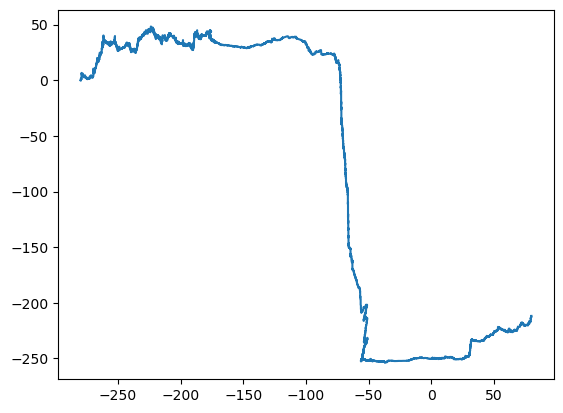

In [151]:
plt.plot(lon_along_contour,
         heat_transp_across_contour.mean('month').sum('rho2_l').cumsum()/1e12)

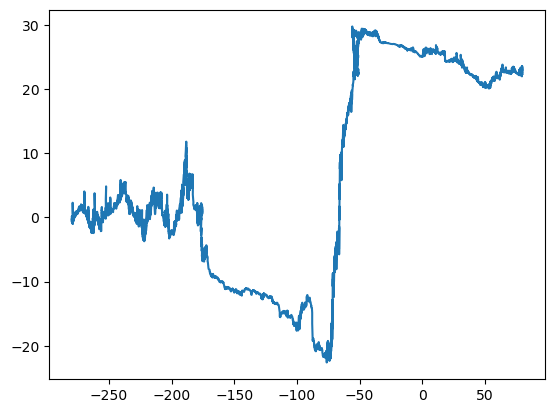

In [72]:
plt.plot(lon_along_contour,
         heat_transp_across_contour.mean('month').sum('z_l').cumsum()/1e12)

In [ ]:
	# convert to longitude coordinate and average into 3 degree longitude bins:
	# in degrees:
	
	bin_width = 3
	bin_spacing = 0.25
	lon_west = -280
	lon_east = 80
	ndays_month=12 # in this code will be the number of time indexes, months in the case
	# new coordinate and midpoints of longitude bins:
	full_lon_coord = np.arange(lon_west,lon_east+bin_spacing,bin_spacing)
	lon_bin_midpoints = np.arange(lon_west+bin_width/2,lon_east-bin_width/2,bin_spacing)
	n_bin_edges = len(full_lon_coord)
	
	# sum into longitude bins:
	# need to be very careful of loops, we can't just mask over longitude values, but instead pick indices 
	# on the isobath contour and sum continously along contour between defined indices.
	# (i.e. lon_along_contour is not monotonic)
	# find points on contour to define edges of longitude bins:
	bin_edge_indices = np.zeros(n_bin_edges)
	for lon_bin in range(n_bin_edges-1):
		# find first isobath point that has the right longitude:
		first_point = np.where(lon_along_contour>=full_lon_coord[lon_bin])[0][0]
		# then find all other isobath points with the same longitude as that first point:
		same_lon_points = np.where(lon_along_contour==lon_along_contour[first_point])[0]
		# we want the most southerly of these points on the same longitude line:
		bin_edge_indices[lon_bin] = same_lon_points[np.argmin(lat_along_contour[same_lon_points])]
	
	# define east/west edges:
	bin_edge_indices = bin_edge_indices.astype(int)
	bin_edge_indices_west = bin_edge_indices[:-int(bin_width/bin_spacing)-1]
	bin_edge_indices_east = bin_edge_indices[int(bin_width/bin_spacing):-1]
	n_bins = len(bin_edge_indices_west)
	
	# sum heat transport from isobath coord into new longitude coord:
	cross_slope_heat_trans = np.zeros([ndays_month,75,n_bins])
	for lon_bin in range(n_bins):
		heat_trans_this_bin0 = heat_transp_across_contour[:,:,bin_edge_indices_west[lon_bin]:bin_edge_indices_east[lon_bin]]
		cross_slope_heat_trans[:,:,lon_bin] = np.sum(heat_trans_this_bin0,axis=2)
	
	#cross_slope_heat_trans=np.zeros([ndays_month,75,int(np.size(lon_bin_midpoints))])	
	#cross_slope_heat_trans[ndindex][nzindex]=cross_slope_heat_trans0
	# find average latitude of each bin, so we can plot back on the isobath:
	lat_bin_midpoints = np.zeros(n_bins)
	for lon_bin in range(n_bins):
		# find nearest isobath point:
		lon_index = np.where(lon_along_contour>=lon_bin_midpoints[lon_bin])[0][0]
		lat_bin_midpoints[lon_bin] = lat_along_contour[lon_index]
	
	print('Calculating Zonal heat convergence')
	# Need to make sure the zonal boundaries here match exactly with the zonal boundaries used for the 
	# longitude averaging above, by using same bin_edge_indices.
	# Just check if isobath point is on x or y grid. if x, sum up to this point from south.
	# if on y grid, sum zonal transport on nearest u grid point to west.
	
	zonal_heat_trans_west = np.zeros([ndays_month,75,n_bins])
	for lon_bin in range(n_bins):
		# west limit:
		# reset these to False:
		on_x_grid = False
		on_y_grid = False
		# mask_x_transport_numbered etc indexing starts from 1 not 0, so add 1:
		isobath_west_index = int(bin_edge_indices_west[lon_bin]+1)
		# check if the point is on the x or y transport grid:
		if len(np.where(mask_x_transport_numbered==isobath_west_index)[0])>0:
			on_x_grid = True
			jj = int(np.where(mask_x_transport_numbered==isobath_west_index)[0])
			ii = int(np.where(mask_x_transport_numbered==isobath_west_index)[1])
		elif len(np.where(mask_y_transport_numbered==isobath_west_index)[0])>0:
			on_y_grid = True
			jj = int(np.where(mask_y_transport_numbered==isobath_west_index)[0])
			ii = int(np.where(mask_y_transport_numbered==isobath_west_index)[1])               
		if on_x_grid == True:
			zonal_heat_trans_west[:,:,lon_bin] = np.sum(temp_xflux_month[:,:,:jj,ii],axis=2)
		#in this case we want transport half a grid point to the west:
		elif on_y_grid == True:
			# careful if ii=0, then we need heat trans from lon=80, because at limit of zonal grid
			if ii==0:
				zonal_heat_trans_west[:,:,lon_bin] = np.sum(temp_xflux_month[:,:,:jj+1,-1],axis=2)
			else:
				zonal_heat_trans_west[:,:,lon_bin] = np.sum(temp_xflux_month[:,:,:jj+1,ii-1],axis=2)
	
	zonal_heat_trans_east = np.zeros([ndays_month,75,n_bins])
	for lon_bin in range(n_bins):
		# east limit:
		# reset these to False:
		on_x_grid = False
		on_y_grid = False
		# mask_x_transport_numbered etc indexing starts from 1 not 0, so add 1:
		isobath_east_index = int(bin_edge_indices_east[lon_bin]+1)
		# check if the point is on the x or y transport grid:
		if len(np.where(mask_x_transport_numbered==isobath_east_index)[0])>0:
			on_x_grid = True
			jj = int(np.where(mask_x_transport_numbered==isobath_east_index)[0])
			ii = int(np.where(mask_x_transport_numbered==isobath_east_index)[1])
		elif len(np.where(mask_y_transport_numbered==isobath_east_index)[0])>0:
			on_y_grid = True
			jj = int(np.where(mask_y_transport_numbered==isobath_east_index)[0])
			ii = int(np.where(mask_y_transport_numbered==isobath_east_index)[1])
		if on_x_grid == True:
			zonal_heat_trans_east[:,:,lon_bin] = np.sum(temp_xflux_month[:,:,:jj,ii],axis=2)
			# in this case we want transport half a grid point to the west:
		elif on_y_grid == True:
			# wrap around to east side of grid:
			if ii==0:
				zonal_heat_trans_east[:,:,lon_bin] = np.sum(temp_xflux_month[:,:,:jj+1,-1],axis=2)
			else:
				zonal_heat_trans_east[:,:,lon_bin] = np.sum(temp_xflux_month[:,:,:jj+1,ii-1],axis=2)
	
	zonal_convergence = zonal_heat_trans_east - zonal_heat_trans_west
	
	
	

## Saving

In [ ]:
	
	save_dir  = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan01/CSHT_mean_CPrhoUhT/Panan01_Ant_cross_slope_heat_terms_offline_'+str(isobath_depth)+'m_'+ start_time+'_rho2.nc'
	
	
	data_ZC=xr.DataArray((zonal_convergence),name="zonal_convergence",dims=["month","rho2_l","lon_bin_midpoints"])
	data_CSHT=xr.DataArray((cross_slope_heat_trans),name="binned_cross_slope_heat_trans",dims=["month","rho2_l","lon_bin_midpoints"])
	data_HT=heat_transp_across_contour
	data_HT.name='unbinned_heat_transp_across_contour'
	data_lat=xr.DataArray((lat_along_contour),name="lat_along_contour",dims=["contour_index"])
	data_lon=xr.DataArray((lon_along_contour),name="lon_along_contour",dims=["contour_index"])
	data_latbin=xr.DataArray((lat_bin_midpoints),name="lat_bin_midpoints",dims=["lon_bin_midpoints"])
	
	
	
	#data_time=xr.DataArray(Ualong.time,name="time",dims=["time"])
	
	data_to_saveuv = xr.merge([data_ZC,data_CSHT,data_HT,data_lat,data_lon,data_latbin])
	data_to_saveuv['contour_index']=heat_transp_across_contour.contour_index
	data_to_saveuv['rho2_l']=np.array(heat_transp_across_contour.rho2_l)
	data_to_saveuv['lon_bin_midpoints']=np.array(lon_bin_midpoints)
	data_to_saveuv['month']=heat_transp_across_contour.month
	data_to_saveuv.to_netcdf(save_dir)
	
	print('Finished successful')
	

testing the organizing data

In [ ]:
data_to_saveuv.binned_cross_slope_heat_trans.mean('month').sum('rho2_l').cumsum().plot()

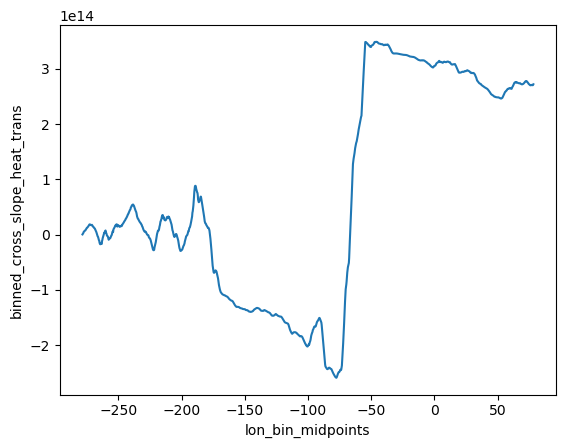

In [77]:
data_to_saveuv.binned_cross_slope_heat_trans.mean('month').sum('z_l').cumsum().plot()

# Checking it

This part doesnt go to the main python code

In [84]:
factor= np.sum(np.mean(heat_transp_across_contour,axis=0) /(np.nansum(np.nansum(np.mean(cross_slope_heat_trans,axis=0),axis=0)) +
                                                     np.nansum(np.nansum(np.mean(zonal_convergence,axis=0),axis=0)))).values
factor

array(0.08168006)

(1500.0, 0.0)

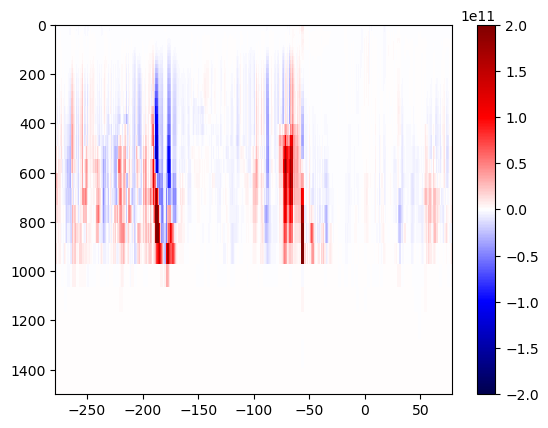

In [80]:
plt.pcolormesh(data_to_saveuv.lon_bin_midpoints,data_to_saveuv.z_l,
               data_to_saveuv.binned_cross_slope_heat_trans.mean('month')*factor,cmap='seismic',vmin=-2e11,vmax=2e11)
plt.colorbar()
plt.ylim(1500,0)

In [ ]:
HT=np.cumsum(np.nansum(np.mean(heat_transp_across_contour,axis=0),axis=0))
CSHT=np.cumsum(np.nansum(np.mean(cross_slope_heat_trans,axis=0),axis=0))*factor
CSHT_ZC=np.cumsum(np.nansum(np.mean(cross_slope_heat_trans+zonal_convergence,axis=0),axis=0))*factor
ZC=np.cumsum(np.nansum(np.mean(zonal_convergence,axis=0),axis=0))*factor

plt.plot(lon_along_contour,HT/1e12,label='HT')
plt.plot(lon_bin_midpoints,CSHT/1e12,label='binned HT')
plt.plot(lon_bin_midpoints,ZC/1e12,label='ZC')
plt.plot(lon_bin_midpoints,CSHT_ZC/1e12,label='binned HT + ZC')

plt.legend()

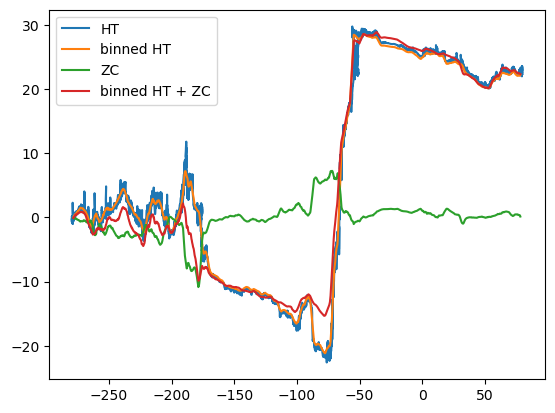

In [86]:
HT=np.cumsum(np.nansum(np.mean(heat_transp_across_contour,axis=0),axis=0))
CSHT=np.cumsum(np.nansum(np.mean(cross_slope_heat_trans,axis=0),axis=0))*factor
CSHT_ZC=np.cumsum(np.nansum(np.mean(cross_slope_heat_trans+zonal_convergence,axis=0),axis=0))*factor
ZC=np.cumsum(np.nansum(np.mean(zonal_convergence,axis=0),axis=0))*factor

plt.plot(lon_along_contour,HT/1e12,label='HT')
plt.plot(lon_bin_midpoints,CSHT/1e12,label='binned HT')
plt.plot(lon_bin_midpoints,ZC/1e12,label='ZC')
plt.plot(lon_bin_midpoints,CSHT_ZC/1e12,label='binned HT + ZC')

plt.legend()

THere is something weird about the zonal velocities in the Antarctic Peninsula in Panan01. LEts check it.